In [1]:
import os
os.chdir("..") # should be run from repo root
from t2Interp.T2I import T2IModel
from t2Interp.intervention import EncoderAttentionIntervention, ScalingAttentionIntervention #, InterventionRunner
from tqdm import tqdm

/home/ubuntu/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## loading the model

In [2]:
model = T2IModel("CompVis/stable-diffusion-v1-4", device="cuda:0", dtype="float16")

2025-11-28 03:13:01.707 | INFO     | t2Interp.T2I:__init__:108 - Enforcing eager attention implementation for attention pattern tracing. The HF default would be to use sdpa if available. To use sdpa, set attn_implementation='sdpa' or None to use the HF default.
Keyword arguments {'attn_implementation': 'eager', 'tokenizer_kwargs': {}, 'trust_remote_code': False} are not expected by StableDiffusionPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 20.62it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases t

In [3]:
# list easy access properties
model._wrappers

{'text_encoder_2': blocks:
 0: in_ | attn_in | attn_out | WO_in | WO_out | mlp_in | mlp_out | out_ | q_in | k_in | v_in | q_out | k_out | v_out
 1: in_ | attn_in | attn_out | WO_in | WO_out | mlp_in | mlp_out | out_ | q_in | k_in | v_in | q_out | k_out | v_out
 2: in_ | attn_in | attn_out | WO_in | WO_out | mlp_in | mlp_out | out_ | q_in | k_in | v_in | q_out | k_out | v_out
 3: in_ | attn_in | attn_out | WO_in | WO_out | mlp_in | mlp_out | out_ | q_in | k_in | v_in | q_out | k_out | v_out
 4: in_ | attn_in | attn_out | WO_in | WO_out | mlp_in | mlp_out | out_ | q_in | k_in | v_in | q_out | k_out | v_out
 5: in_ | attn_in | attn_out | WO_in | WO_out | mlp_in | mlp_out | out_ | q_in | k_in | v_in | q_out | k_out | v_out
 6: in_ | attn_in | attn_out | WO_in | WO_out | mlp_in | mlp_out | out_ | q_in | k_in | v_in | q_out | k_out | v_out
 7: in_ | attn_in | attn_out | WO_in | WO_out | mlp_in | mlp_out | out_ | q_in | k_in | v_in | q_out | k_out | v_out
 8: in_ | attn_in | attn_out | WO_in 

In [4]:
from utils.inference import Inference, InferenceSpec
from t2Interp.intervention import run_intervention

In [20]:
import os
#os.chdir("home/ubuntu/narmeen-t2I-sae/T2I_Interp_toolkit")
from dictionary_learning.trainers.top_k import AutoEncoderTopK

In [25]:
import torch
sd = torch.load("../sdxl-unbox/checkpoints/unet.down_blocks.2.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth", map_location="cuda:0")
sd = sd['state_dict']
sd = {k.replace("pre_bias","b_dec"): v for k, v in sd.items() if k in ["encoder.weight","pre_bias","decoder.weight"]}
sd.update({"encoder.bias": torch.zeros((5120,)), "k": torch.tensor(10), "threshold" : torch.tensor(-1.0)})
torch.save(sd, "../sdxl-unbox/checkpoints/unet.down_blocks.2.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth")

sd = torch.load("../sdxl-unbox/checkpoints/unet.mid_block.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth", map_location="cuda:0")
sd = sd['state_dict']
sd = {k.replace("pre_bias","b_dec"): v for k, v in sd.items() if k in ["encoder.weight","pre_bias","decoder.weight"]}
sd.update({"encoder.bias": torch.zeros((5120,)), "k": torch.tensor(10), "threshold" : torch.tensor(-1.0)})
torch.save(sd, "../sdxl-unbox/checkpoints/unet.mid_block.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth")

sd = torch.load("../sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth", map_location="cuda:0")
sd = sd['state_dict']
sd = {k.replace("pre_bias","b_dec"): v for k, v in sd.items() if k in ["encoder.weight","pre_bias","decoder.weight"]}
sd.update({"encoder.bias": torch.zeros((5120,)), "k": torch.tensor(10), "threshold" : torch.tensor(-1.0)})
torch.save(sd, "../sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth")

sd = torch.load("../sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth", map_location="cuda:0")
sd = sd['state_dict']
sd = {k.replace("pre_bias","b_dec"): v for k, v in sd.items() if k in ["encoder.weight","pre_bias","decoder.weight"]}
sd.update({"encoder.bias": torch.zeros((5120,)), "k": torch.tensor(10), "threshold" : torch.tensor(-1.0)})
torch.save(sd, "../sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth")

In [27]:
import torch
dtype = torch.float16
sae1= AutoEncoderTopK.from_pretrained("../sdxl-unbox/checkpoints/unet.down_blocks.2.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth", k=10, device="cuda:0",).to(dtype)
# sae2= AutoEncoderTopK.from_pretrained("./sdxl-unbox/checkpoints/unet.mid_block.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth", k=10, device="cuda:0",).to(dtype)
# sae3= AutoEncoderTopK.from_pretrained("./sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth", k=10, device="cuda:0",).to(dtype)
# sae4= AutoEncoderTopK.from_pretrained("./sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth", k=10, device="cuda:0",).to(dtype)

In [30]:
from t2Interp.sae import SAEManager
from t2Interp.T2I import T2IModel
model = T2IModel("stabilityai/sdxl-turbo", device="cuda:0", dtype="float16") 

2025-11-28 03:34:22.075 | INFO     | t2Interp.T2I:__init__:108 - Enforcing eager attention implementation for attention pattern tracing. The HF default would be to use sdpa if available. To use sdpa, set attn_implementation='sdpa' or None to use the HF default.


NOTE: Training on 25000000 tokens


Fetching 18 files: 100%|██████████| 18/18 [00:11<00:00,  1.59it/s]
Keyword arguments {'attn_implementation': 'eager', 'tokenizer_kwargs': {}, 'trust_remote_code': False, 'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 10.63it/s]


In [ ]:
sae_manager = SAEManager(model=model)
kwargs = {"diff":True}
sae1.k=torch.Tensor([5120]).to("cuda:0", dtype=torch.int32)
sae_manager.add_saes_to_model(sae_list=[(model.unet_2.down_attn_blocks[7].cross_attn_out, sae1, "cross_attn_out")],**kwargs)
                                            #     (model.unet_2.mid_attn_block.self_attn_WO_out, sae2, "self_attn_out"),
                                            #    (model.unet_2.up_attn_blocks[0].self_attn_WO_out, sae3, "self_attn_out"),
                                            #    (model.unet_2.up_attn_blocks[1].cross_attn_WO_out, sae4, "cross_attn_out"),
                                            #    ])

In [38]:
from utils.inference import Inference, InferenceSpec
spec = InferenceSpec(name=f"sae feature caching", 
                    inference_fn= sae_manager.run_with_cache,
                    kwargs={"prompt":"A cinematic shot of a professor sloth wearing a tuxedo at a BBQ party.",
                            "accessors" : [model.unet_2.down_attn_blocks[7].cross_attn_out.ae.encoder_out],
                            "num_inference_steps":1, "guidance_scale":0.0, "seed":42,})
inference = Inference(spec)
output=inference.run_inference()

100%|██████████| 1/1 [00:00<00:00,  8.51it/s]


In [41]:
print(output)

Output(preds=defaultdict(<class 'list'>, {'cross_attn_out_encode_out': tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0552, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.3396, 0.0976, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.3669, 0.1257, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0154,  ..., 0.5659, 0.3892, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.5723, 0.3738, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.2771, 0.1042, 0.0000]]],
       dtype=torch.float16)}), baselines=None, labels=None, metrics=None, name='sae feature caching', run_metadata=None, best_ckpt=None)


In [ ]:
sparse_maps = output.preds['cross_attn_out_encode_out']
top_features = sparse_maps.mean(axis=(0, 1)).topk(10).indices.cpu().tolist()
with model.generate("A cinematic shot of a professor sloth wearing a tuxedo at a BBQ party.", num_inference_steps=1, seed=42, guidance_scale=0.) as gen:
    orig = model.output.save()
output.images=[orig.images[0]]


100%|██████████| 1/1 [00:00<00:00,  6.13it/s]


/tmp/ipykernel_8973/3519685032.py:17: RuntimeWarning: invalid value encountered in divide
  heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))


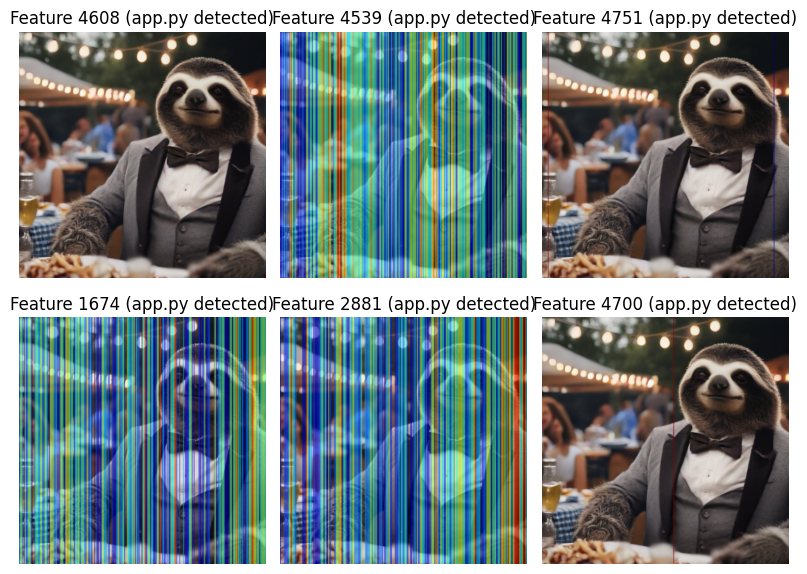

In [51]:
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from PIL import Image

def plot_image_heatmap(output, sparse_maps, feature):
    heatmap = sparse_maps[:, :, feature].cpu().numpy()
    heatmap = np.kron(heatmap, np.ones((32, 32)))
    image = output.images[0]
    image = image.convert("RGBA")
    
    jet = plt.cm.jet
    cmap = jet(np.arange(jet.N))
    cmap[:1, -1] = 0
    cmap[1:, -1] = 0.6
    cmap = ListedColormap(cmap)
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))
    heatmap_rgba = cmap(heatmap)
    heatmap_image = Image.fromarray((heatmap_rgba * 255).astype(np.uint8))
    heatmap_image = heatmap_image.resize(image.size, resample=Image.BILINEAR)
    heatmap_with_transparency = Image.alpha_composite(image, heatmap_image)

    return heatmap_with_transparency
#set the top features
# Hardcoded features detected by app.py approach
# From comparison: app.py top 10 features: [4608, 4539, 4751, 1674, 2881, 4700, 3119, 2345, 1226, 4094]
top_features_app = [4608, 4539, 4751, 1674, 2881, 4700, 3119, 2345, 1226, 4094]

plt.figure(figsize=(8, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(plot_image_heatmap(output, sparse_maps, top_features_app[i]))
    plt.title(f"Feature {top_features_app[i]} (app.py detected)")
    plt.axis("off")
plt.tight_layout()

In [49]:
## ============================================
## SIDE-BY-SIDE COMPARISON: T2I_Interp vs app.py
## ============================================

import sys
import os
import torch
import numpy as np
from pathlib import Path

# Add sdxl-unbox to path for imports
sdxl_path = Path("../sdxl-unbox").resolve()
if str(sdxl_path) not in sys.path:
    sys.path.insert(0, str(sdxl_path))

# Import app.py approach
from SDLens import HookedStableDiffusionXLPipeline
from SAE import SparseAutoencoder

# Define process_cache function directly (to avoid import conflicts)
# This is copied from app.py to avoid importing the whole module
def process_cache(cache, saes_dict, timestep=None):
    """Process cache to extract sparse feature maps - from app.py"""
    code_to_block = {
        "down.2.1": "unet.down_blocks.2.attentions.1",
        "mid.0": "unet.mid_block.attentions.0",
        "up.0.1": "unet.up_blocks.0.attentions.1",
        "up.0.0": "unet.up_blocks.0.attentions.0"
    }
    
    top_features_dict = {}
    sparse_maps_dict = {}
    
    for code in code_to_block.keys():
        block = code_to_block[code]
        if block not in cache["output"] or block not in cache["input"]:
            continue
        if code not in saes_dict:
            continue
            
        sae = saes_dict[code]
        
        diff = cache["output"][block] - cache["input"][block]
        if diff.shape[0] == 2:  # guidance is on and we need to select the second output
            diff = diff[1].unsqueeze(0)
        
        # If a specific timestep is provided, select that timestep from the cached activations
        if timestep is not None and timestep < diff.shape[1]:
            diff = diff[:, timestep:timestep+1]
        
        diff = diff.permute(0, 1, 3, 4, 2).squeeze(0).squeeze(0)
        with torch.no_grad():
            sparse_maps = sae.encode(diff)
        averages = torch.mean(sparse_maps, dim=(0, 1))
        
        top_features = torch.topk(averages, 10).indices
        
        top_features_dict[code] = top_features.cpu().tolist()
        sparse_maps_dict[code] = sparse_maps.cpu().numpy()
    
    return top_features_dict, sparse_maps_dict

print("=" * 60)
print("COMPARISON SETUP")
print("=" * 60)

# Common parameters
PROMPT = "A cinematic shot of a professor sloth wearing a tuxedo at a BBQ party."
NUM_STEPS = 1
GUIDANCE_SCALE = 0.0
SEED = 42
BLOCK = "unet.down_blocks.2.attentions.1"
CODE = "down.2.1"
SAE_PATH = "../sdxl-unbox/checkpoints/unet.down_blocks.2.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final"
DTYPE = torch.float16

print(f"Prompt: {PROMPT}")
print(f"Steps: {NUM_STEPS}, Guidance: {GUIDANCE_SCALE}, Seed: {SEED}")
print(f"Block: {BLOCK}")
print(f"SAE Path: {SAE_PATH}")
print()

# ============================================
# APPROACH 1: T2I_Interp_toolkit (already set up)
# ============================================
print("=" * 60)
print("APPROACH 1: T2I_Interp_toolkit")
print("=" * 60)

# Use existing setup from previous cells
# model, sae_manager, sae1 are already loaded

print("Running T2I_Interp inference...")
spec_t2i = InferenceSpec(
    name="t2i_interp_comparison",
    inference_fn=sae_manager.run_with_cache,
    kwargs={
        "prompt": PROMPT,
        "accessors": [model.unet_2.down_attn_blocks[7].cross_attn_out.ae.encoder_out],
        "num_inference_steps": NUM_STEPS,
        "guidance_scale": GUIDANCE_SCALE,
        "seed": SEED,
    }
)
inference_t2i = Inference(spec_t2i)
output_t2i = inference_t2i.run_inference()

sparse_maps_t2i = output_t2i.preds['cross_attn_out_encode_out']
top_features_t2i = sparse_maps_t2i.mean(axis=(0, 1)).topk(10).indices.cpu().tolist()

print(f"T2I_Interp sparse_maps shape: {sparse_maps_t2i.shape}")
print(f"T2I_Interp sparse_maps dtype: {sparse_maps_t2i.dtype}")
print(f"T2I_Interp top 10 features: {top_features_t2i}")
print(f"T2I_Interp sparse_maps stats:")
print(f"  Min: {sparse_maps_t2i.min().item():.6f}, Max: {sparse_maps_t2i.max().item():.6f}")
print(f"  Mean: {sparse_maps_t2i.mean().item():.6f}, Std: {sparse_maps_t2i.std().item():.6f}")
print()

# ============================================
# APPROACH 2: app.py (HookedStableDiffusionXLPipeline)
# ============================================
print("=" * 60)
print("APPROACH 2: app.py (HookedStableDiffusionXLPipeline)")
print("=" * 60)

# Load model
print("Loading HookedStableDiffusionXLPipeline...")
pipe_app = HookedStableDiffusionXLPipeline.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=DTYPE,
    device_map="balanced",  # Use "balanced" instead of "cuda:0" (accelerate requirement)
    variant="fp16" if DTYPE == torch.float16 else None
)
pipe_app.set_progress_bar_config(disable=True)

# Check if checkpoint was modified (has "b_dec" instead of "state_dict" wrapper)
checkpoint_path = os.path.join(SAE_PATH, 'state_dict.pth')
checkpoint_data = torch.load(checkpoint_path, map_location='cpu')

if 'state_dict' in checkpoint_data:
    # Original format - can load directly
    print("  Found original format, loading...")
    sae_app = SparseAutoencoder.load_from_disk(SAE_PATH)
else:
    # Modified format - convert back to original format for SparseAutoencoder
    print("  Checkpoint was modified in Cell 6. Converting back to original format...")
    import json
    
    # Load config
    with open(os.path.join(SAE_PATH, 'config.json'), 'r') as f:
        cfg = json.load(f)
    
    # Create SAE instance
    sae_app = SparseAutoencoder(
        n_dirs_local=cfg["n_dirs_local"],
        d_model=cfg["d_model"],
        k=cfg["k"],
        auxk=cfg["auxk"],
        dead_steps_threshold=cfg["dead_steps_threshold"],
    )
    
    # Convert modified format back to original
    # Modified format has: encoder.weight, b_dec, decoder.weight, encoder.bias, k, threshold
    # Original format needs: encoder.weight, pre_bias, decoder.weight, latent_bias, stats_last_nonzero
    modified_sd = checkpoint_data
    
    # Map keys: b_dec -> pre_bias
    original_sd = {}
    original_sd['encoder.weight'] = modified_sd['encoder.weight']
    original_sd['decoder.weight'] = modified_sd['decoder.weight']
    original_sd['pre_bias'] = modified_sd.get('b_dec', torch.zeros(cfg["d_model"]))
    original_sd['latent_bias'] = torch.zeros(cfg["n_dirs_local"])  # Not in modified format, use zeros
    original_sd['stats_last_nonzero'] = torch.zeros(cfg["n_dirs_local"], dtype=torch.long)  # Not in modified format
    
    sae_app.load_state_dict(original_sd)
    print("  Converted and loaded successfully!")

sae_app = sae_app.to('cuda:0', dtype=DTYPE)

# Create saes_dict for process_cache
saes_dict_app = {CODE: sae_app}

print("Running app.py inference...")
images_app, cache_app = pipe_app.run_with_cache(
    PROMPT,
    positions_to_cache=[BLOCK],
    num_inference_steps=NUM_STEPS,
    generator=torch.Generator(device="cpu").manual_seed(SEED),
    guidance_scale=GUIDANCE_SCALE,
    save_input=True,
    save_output=True
)

# Process cache using app.py's process_cache function
top_features_dict_app, sparse_maps_dict_app = process_cache(cache_app, saes_dict_app, timestep=None)

sparse_maps_app = torch.from_numpy(sparse_maps_dict_app[CODE])
top_features_app = top_features_dict_app[CODE]

print(f"app.py sparse_maps shape: {sparse_maps_app.shape}")
print(f"app.py sparse_maps dtype: {sparse_maps_app.dtype}")
print(f"app.py top 10 features: {top_features_app}")
print(f"app.py sparse_maps stats:")
print(f"  Min: {sparse_maps_app.min().item():.6f}, Max: {sparse_maps_app.max().item():.6f}")
print(f"  Mean: {sparse_maps_app.mean().item():.6f}, Std: {sparse_maps_app.std().item():.6f}")
print()


# Convert to same dtype and device for comparison
sparse_maps_t2i_comp = sparse_maps_t2i.cpu().float()
sparse_maps_app_comp = sparse_maps_app.float()

# Check shapes
shape_match = sparse_maps_t2i_comp.shape == sparse_maps_app_comp.shape
print(f"Shape match: {shape_match}")
if not shape_match:
    print(f"  T2I_Interp shape: {sparse_maps_t2i_comp.shape}")
    print(f"  app.py shape: {sparse_maps_app_comp.shape}")

# Check top features
top_features_match = top_features_t2i == top_features_app
print(f"Top 10 features match: {top_features_match}")
if not top_features_match:
    print(f"  T2I_Interp: {top_features_t2i}")
    print(f"  app.py:     {top_features_app}")

# Compute differences
if shape_match:
    diff = sparse_maps_t2i_comp - sparse_maps_app_comp
    abs_diff = torch.abs(diff)
    max_diff = abs_diff.max().item()
    mean_diff = abs_diff.mean().item()
    std_diff = abs_diff.std().item()
    
    print(f"\nDifference Statistics:")
    print(f"  Max absolute difference: {max_diff:.6f}")
    print(f"  Mean absolute difference: {mean_diff:.6f}")
    print(f"  Std of differences: {std_diff:.6f}")
    
    # Relative error
    max_val = max(sparse_maps_t2i_comp.abs().max(), sparse_maps_app_comp.abs().max())
    relative_error = (max_diff / max_val * 100) if max_val > 0 else 0
    print(f"  Max relative error: {relative_error:.4f}%")
    
    # Check if differences are within tolerance (accounting for float16 precision)
    tolerance = 1e-3  # Reasonable tolerance for float16
    within_tolerance = max_diff < tolerance
    print(f"  Within tolerance ({tolerance}): {within_tolerance}")
    
    if not within_tolerance:
        print(f"\n  WARNING: Differences exceed tolerance!")
    else:
        print(f"\nResults are within acceptable tolerance!")



COMPARISON SETUP
Prompt: A cinematic shot of a professor sloth wearing a tuxedo at a BBQ party.
Steps: 1, Guidance: 0.0, Seed: 42
Block: unet.down_blocks.2.attentions.1
SAE Path: ../sdxl-unbox/checkpoints/unet.down_blocks.2.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final

APPROACH 1: T2I_Interp_toolkit
Running T2I_Interp inference...


100%|██████████| 1/1 [00:00<00:00,  8.80it/s]


T2I_Interp sparse_maps shape: torch.Size([1, 256, 5120])
T2I_Interp sparse_maps dtype: torch.float16
T2I_Interp top 10 features: [3410, 3906, 720, 3924, 4672, 2554, 4057, 4426, 4331, 2459]
T2I_Interp sparse_maps stats:
  Min: 0.000000, Max: 1.580078
  Mean: 0.131348, Std: 0.184082

APPROACH 2: app.py (HookedStableDiffusionXLPipeline)
Loading HookedStableDiffusionXLPipeline...


Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  1.99it/s]


  Checkpoint was modified in Cell 6. Converting back to original format...
  Converted and loaded successfully!
Running app.py inference...
app.py sparse_maps shape: torch.Size([16, 16, 5120])
app.py sparse_maps dtype: torch.float16
app.py top 10 features: [4608, 4539, 4751, 1674, 2881, 4700, 3119, 2345, 1226, 4094]
app.py sparse_maps stats:
  Min: 0.000000, Max: 84.250000
  Mean: 0.029083, Std: 0.713867

Shape match: False
  T2I_Interp shape: torch.Size([1, 256, 5120])
  app.py shape: torch.Size([16, 16, 5120])
Top 10 features match: False
  T2I_Interp: [3410, 3906, 720, 3924, 4672, 2554, 4057, 4426, 4331, 2459]
  app.py:     [4608, 4539, 4751, 1674, 2881, 4700, 3119, 2345, 1226, 4094]
